In [1]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
# https://raw.githubusercontent.com/dataprofessor/
# data/refs/heads/master/penguins_cleaned.csv
url = "https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/penguins_cleaned.csv"
df = pd.read_csv(url)
df.head(1)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,male


In [3]:
for c in df.columns:
    print(c)

species
island
bill_length_mm
bill_depth_mm
flipper_length_mm
body_mass_g
sex


In [4]:
df.corr(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


In [8]:
x_str = "body_mass_g"
y_str = "flipper_length_mm"
x = df[x_str]
y = df[y_str]
type(x)

pandas.Series

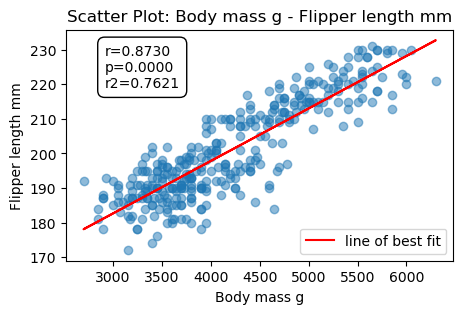

In [ ]:
r, p = stats.pearsonr(x,y)
r2 = r**2

x_name = x_str.replace("_", " ").capitalize()
y_name = y_str.replace("_", " ").capitalize()
plt.figure(figsize=(5,3))
plt.scatter(x,y,alpha=0.5)
plt.title(f"Scatter Plot: {x_name} - {y_name}")
plt.xlabel(x_name)
plt.ylabel(y_name)
text = f"""r={r:.4f}
p={p:.4f}
r2={r2:.4f}"""
plt.text(
    0.1,
    0.75,
    text,
    transform=plt.gca().transAxes,
    bbox={"boxstyle": "round, pad=0.5", "fc": "white"}
)
# add line of best fit.
m, b, r, p, err = stats.linregress(x,y)
line = m * x + b # returns [..,..,..,..,..,..]
plt.plot(x, line, color="r", label="line of best fit")
plt.legend()
plt.show()

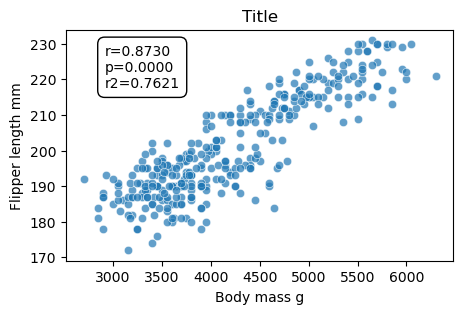

In [14]:
# Scatter with Seaborn
plt.figure(figsize=(5,3))
scat = sns.scatterplot(data=df, x=x_str, y=y_str, alpha=0.7)
scat.set(xlabel= x_name, ylabel=y_name, title="Title")
scat.text(
    0.1,
    0.75,
    text,
    transform=scat.transAxes,
    bbox={"boxstyle": "round, pad=0.5", "fc": "white"}
)
plt.show()

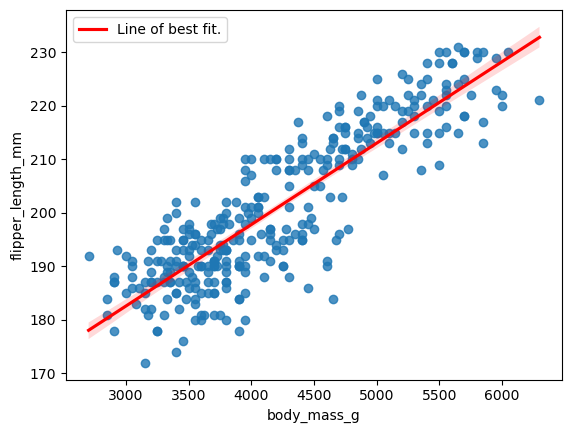

In [16]:
sns.regplot(data=df, x=x_str, y=y_str, line_kws={"color": "red", "label":"Line of best fit."})
plt.legend()

In [22]:
species = df["species"].unique()
species

<StringArray>
['Adelie', 'Gentoo', 'Chinstrap']
Length: 3, dtype: str

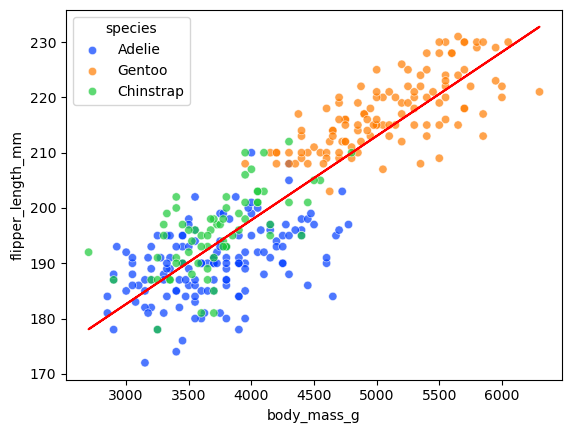

In [27]:
sns.scatterplot(data=df, x=x_str, y=y_str, hue="species", palette="bright", alpha=0.7)
plt.plot(x,line,color="r")

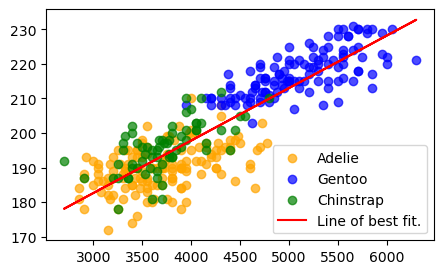

In [31]:
plt.figure(figsize=(5,3))
colors = ["orange", "blue", "green"]
for s in species:
    subset = df.loc[df["species"] == s]
    plt.scatter(subset[x_str], subset[y_str],alpha=0.7, color=colors.pop(0), label=s)

plt.plot(x,line,color="r", label="Line of best fit.")
plt.legend()
plt.show()

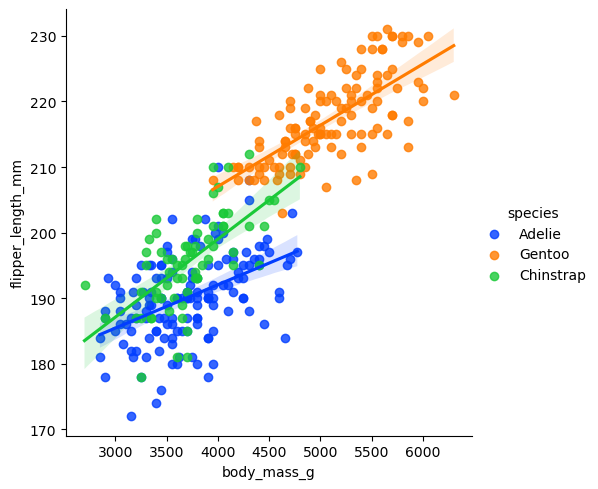

In [32]:
sns.lmplot(
    data=df,
    x=x_str,
    y=y_str,
    hue="species",
    palette="bright"
)

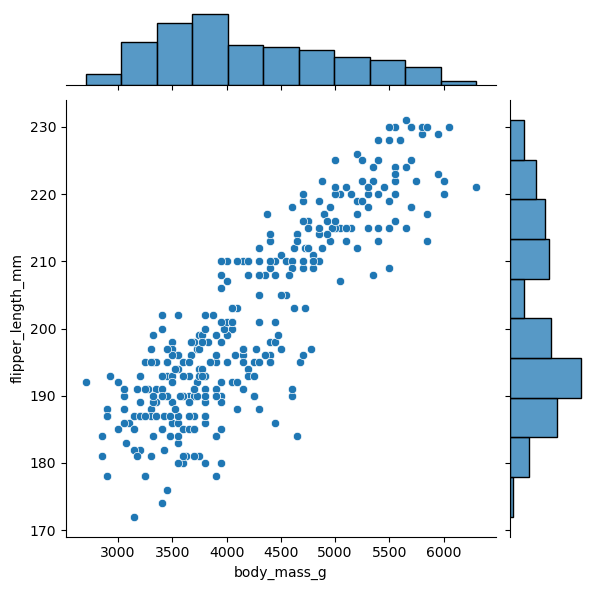

In [33]:
sns.jointplot(data=df, x=x_str, y=y_str)

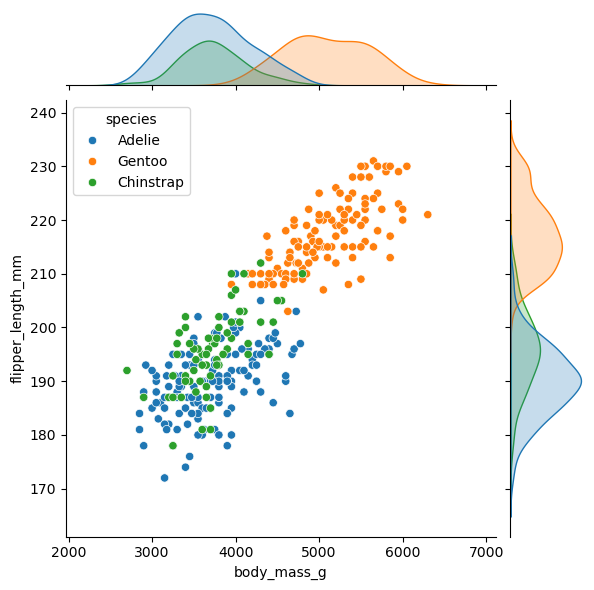

In [35]:
sns.jointplot(data=df, x=x_str, y=y_str,hue="species")